# Сканирование коэффициента заразности

Для каждого $\beta\in[0.1,1.0]$ выполняются три стохастических прогона.
Эпидемией считается опыт, где пик превышает 5% начальной популяции.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames, Statistics
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Полный факторный расчёт

In [2]:
rows = NamedTuple[]
for beta in 0.1:0.1:1.0, seed in 42:44
    _, history = run_sir(Ns=[1000, 1000, 1000], β_und=fill(beta, 3),
        β_det=fill(beta / 10, 3), infection_period=14, detection_time=7,
        death_rate=0.02, reinfection_probability=0.1, Is=[0, 0, 1],
        seed=seed, n_steps=100)
    push!(rows, merge((beta=beta, seed=seed, R0=basic_reproduction_number(beta, 14)),
                      epidemic_metrics(DataFrame(history), 3000)))
end
all_runs = save_frame(DataFrame(rows), "sir-scan-beta", "beta-scan-all.csv")
summary = combine(groupby(all_runs, [:beta, :R0]),
    :peak_fraction => mean => :mean_peak_fraction,
    :peak_fraction => std => :sd_peak_fraction,
    :deaths => mean => :mean_deaths,
    :attack_rate => mean => :mean_attack_rate)
summary.epidemic = summary.mean_peak_fraction .> 0.05
save_frame(summary, "sir-scan-beta", "beta-scan-summary.csv")
observed_threshold = minimum(summary.beta[summary.epidemic])
threshold = DataFrame(observed_beta=[observed_threshold],
    observed_R0=[14 * observed_threshold], theoretical_beta=[1 / 14], theoretical_R0=[1.0])
save_frame(threshold, "sir-scan-beta", "epidemic-threshold.csv")

Row,observed_beta,observed_R0,theoretical_beta,theoretical_R0
,Float64,Float64,Float64,Float64
1,0.2,2.8,0.0714286,1.0


## Порог и нагрузка

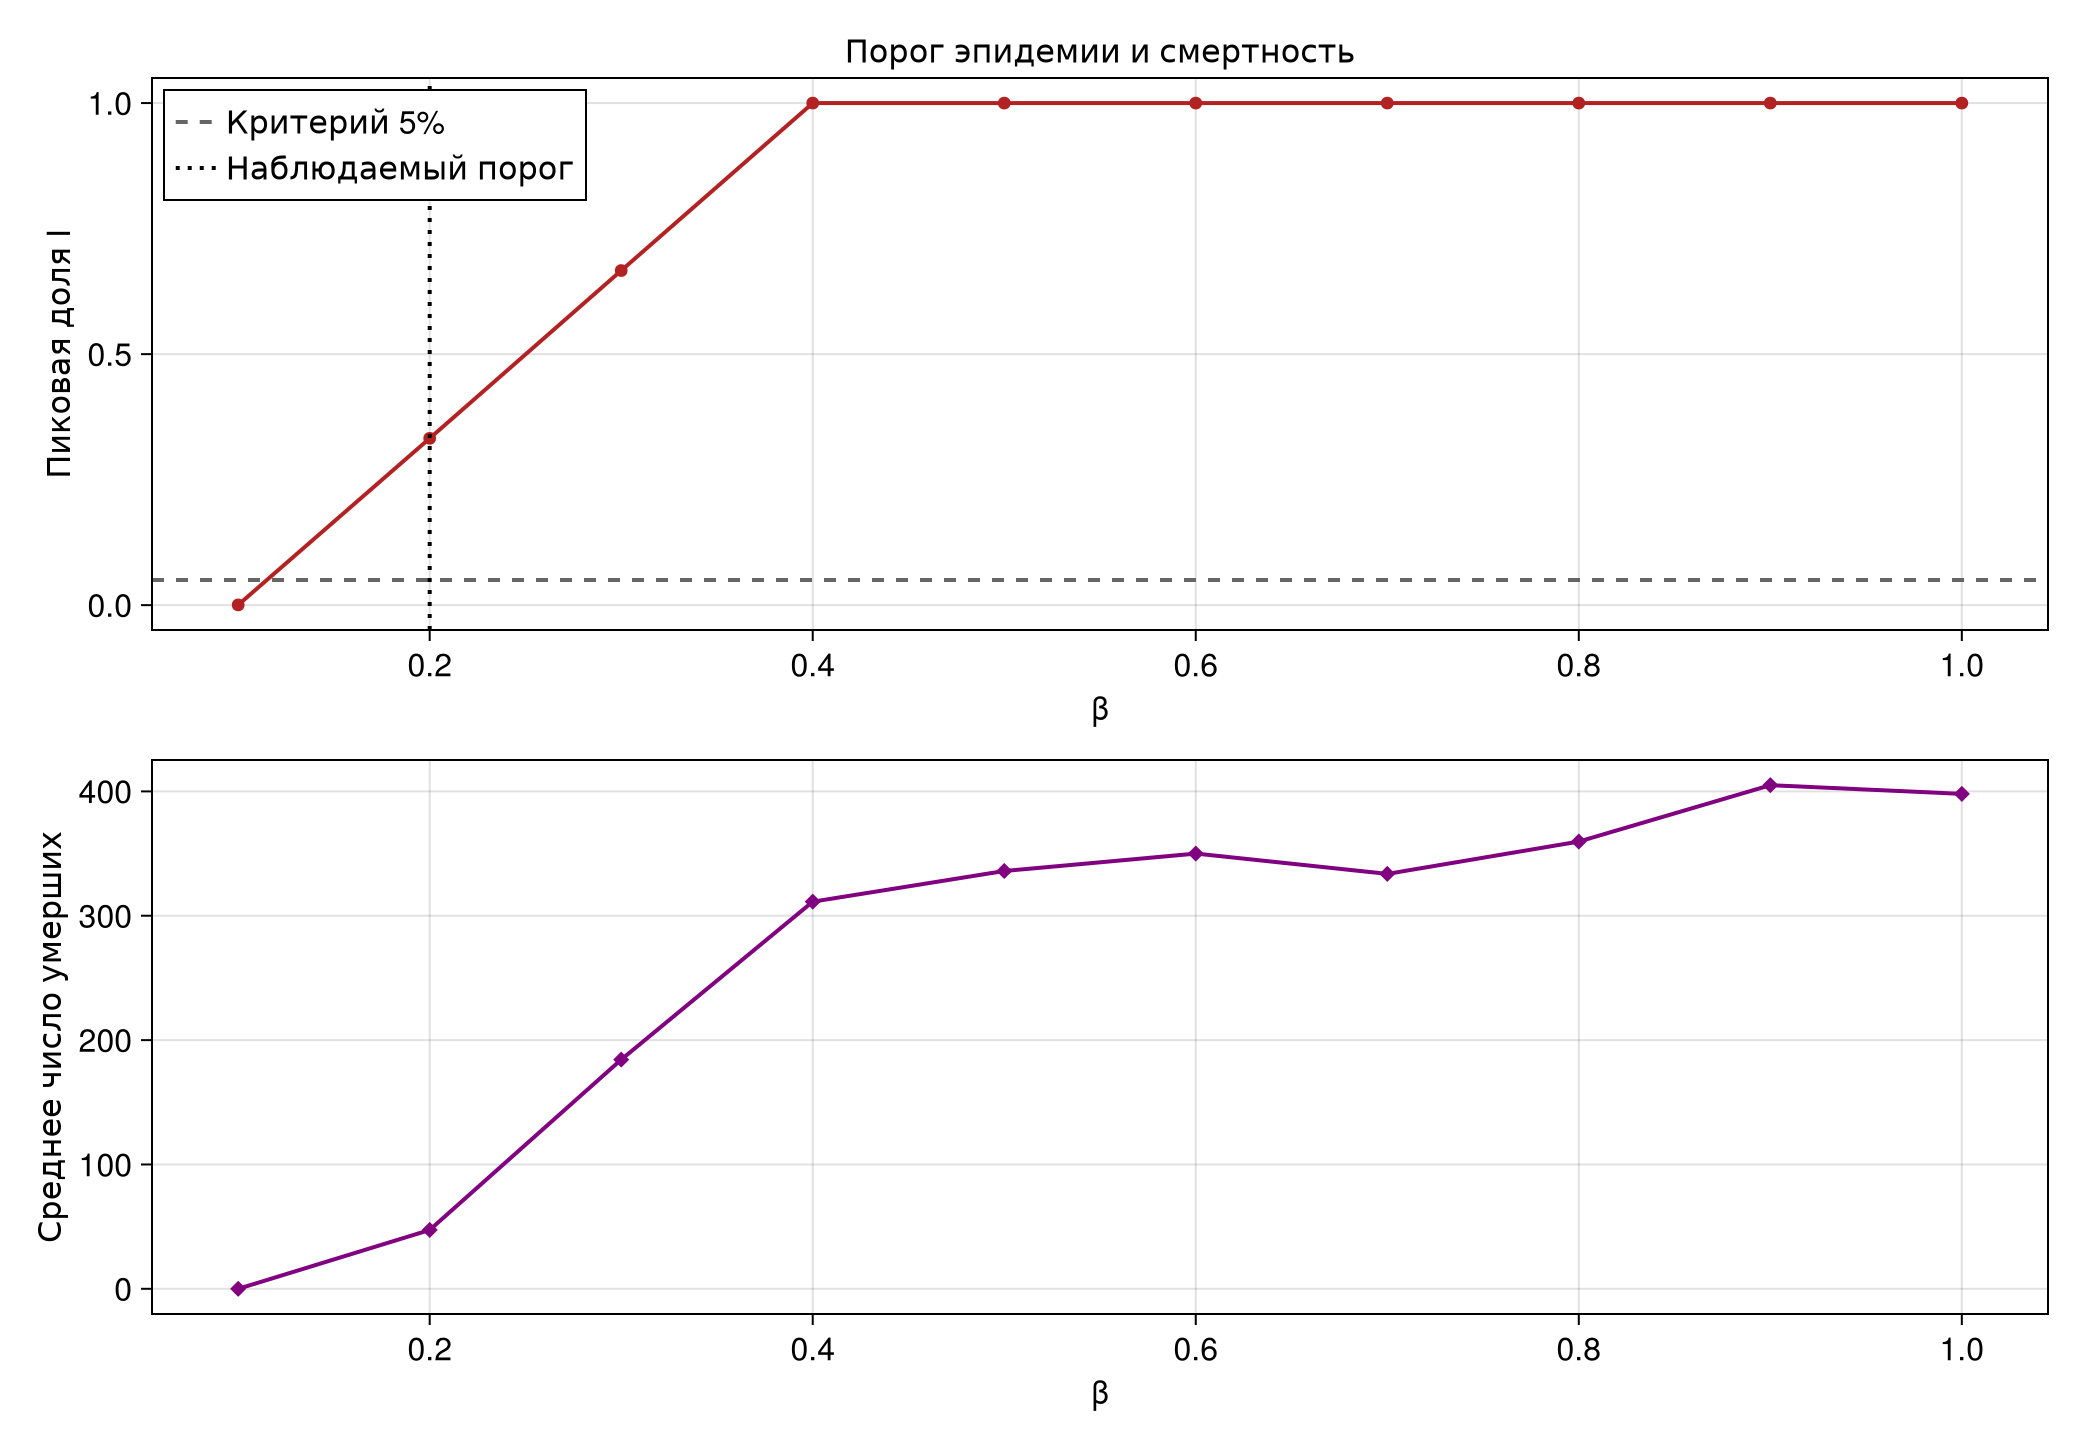

Row,observed_beta,observed_R0,theoretical_beta,theoretical_R0
,Float64,Float64,Float64,Float64
1,0.2,2.8,0.0714286,1.0


In [3]:
fig = Figure(size=(1040, 720))
ax1 = Axis(fig[1, 1], title="Порог эпидемии и смертность", xlabel="β", ylabel="Пиковая доля I")
scatterlines!(ax1, summary.beta, summary.mean_peak_fraction; marker=:circle, color=:firebrick)
hlines!(ax1, [0.05]; linestyle=:dash, color=:gray40, label="Критерий 5%")
vlines!(ax1, [observed_threshold]; linestyle=:dot, color=:black, label="Наблюдаемый порог")
axislegend(ax1; position=:lt)
ax2 = Axis(fig[2, 1], xlabel="β", ylabel="Среднее число умерших")
scatterlines!(ax2, summary.beta, summary.mean_deaths; marker=:diamond, color=:purple)
save_figure(fig, "sir-scan-beta", "beta-scan.png"; report_name="sir-beta-threshold.png")
display(fig)
threshold